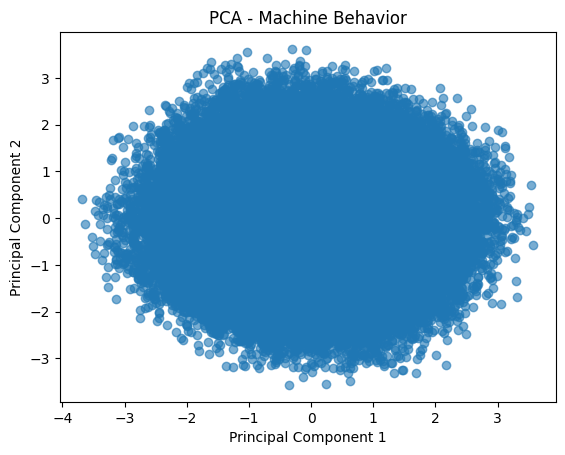

[0.11280493 0.11222922]
Total variance captured: 0.22503414664209215
     Temperature_C  Vibration_Hz  Power_Consumption_kW  Network_Latency_ms  \
PC1      -0.073682      0.388031              0.213921            0.283927   
PC2      -0.438015      0.008739             -0.426994            0.539397   

     Packet_Loss_%  Quality_Control_Defect_Rate_%  \
PC1      -0.376405                      -0.153709   
PC2      -0.415217                       0.212593   

     Production_Speed_units_per_hr  Predictive_Maintenance_Score  Error_Rate_%  
PC1                       0.460624                      0.314921      0.490885  
PC2                      -0.176251                     -0.271838     -0.110597  


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("manufacturing_6G_dataset.csv")

# Select numerical features
features = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%',
    'Quality_Control_Defect_Rate_%',
    'Production_Speed_units_per_hr',
    'Predictive_Maintenance_Score',
    'Error_Rate_%'
]

X = df[features]

# Step 1: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Add label for interpretation
pca_df['Efficiency_Status'] = df['Efficiency_Status']

# Plot
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Machine Behavior")
plt.show()



## HOW MUCH INFORMATION DID WE RETAIN?
print(pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1', 'PC2']
)

print(loadings)
